# 19 — Uncapped CD8-OOD data prep — narrated comparison

Companion to `19_uncapped_cd8_ood_data_prep.py` (the headless script used for batch execution). Same pipeline, but with markdown context, the actual numbers loaded from the script's outputs, and richer per-cell-type comparisons. **No heavy re-computation here** — we read the CSV / h5ad artifacts the script already produced under `speciesOT/baseline/analysis/uncapped_outputs/` and `cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/`.

## TL;DR

- Existing baseline `hvg_pearson_residuals_a_ood/impact_cellot` was trained on data derived from `sampled_*_shared.h5ad`, where each cell type was **capped at 1000 cells per species** in the upstream sampling step (`tabula_make_samples.ipynb`).
- This notebook documents the **identical 01.5 pipeline** (no v2/v3 assay filter; 1:1 (cell_type, tissue) match; pearson_residuals HVG with `batch_key='species'`; toggle_ood/CD8 holdout) but reading from `tabula_*_all.h5ad` (uncapped) instead.
- Matched-pair count goes from **6,495 → 62,443 (9.6× larger)**.
- Held-out CD8 evaluation cells go from **390 → 2,996 stacked (7.7× more eval material)**.
- New trained models will live under `cellot/cellot_gpu/results/hvg_pearson_residuals_a_ood_uncapped/{scgen,impact_cellot}/`.

## Why this exists

We want to measure the **causal effect of upstream data-set size on the trained CellOT model**, holding the rest of the pipeline byte-identical. The only difference vs the existing baseline is the absence of the per-cell-type 1000-cap in the upstream sampling. If this change moves R² and MMD on the held-out CD8 evaluation, removing the cap is a defensible cheap win. If it doesn't, that's also informative — it would suggest the bottleneck is elsewhere (model design, hyperparameters, or the OT objective itself).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

BASE = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT")
DATASET_DIR = BASE / "cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg"
OUT_DIR = BASE / "speciesOT/baseline/analysis/uncapped_outputs"

CAPPED_H5 = DATASET_DIR / "hvg_pearson_residuals_a_v07.h5ad"
UNCAPPED_H5 = DATASET_DIR / "hvg_pearson_residuals_a_uncapped_v07.h5ad"
SUMMARY_CSV = OUT_DIR / "before_after_summary.csv"
PERCELLTYPE_CSV = OUT_DIR / "per_celltype_counts.csv"

print("capped h5ad   :", CAPPED_H5, "exists?", CAPPED_H5.exists())
print("uncapped h5ad :", UNCAPPED_H5, "exists?", UNCAPPED_H5.exists())
print("summary csv   :", SUMMARY_CSV, "exists?", SUMMARY_CSV.exists())
print("per-ct csv    :", PERCELLTYPE_CSV, "exists?", PERCELLTYPE_CSV.exists())


capped h5ad   : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_a_v07.h5ad exists? True
uncapped h5ad : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_a_uncapped_v07.h5ad exists? True
summary csv   : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/uncapped_outputs/before_after_summary.csv exists? True
per-ct csv    : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/uncapped_outputs/per_celltype_counts.csv exists? True


## 1. What the 1000-cap was doing (upstream)

The function lives in `speciesOT/tabula_make_samples.ipynb`. It was applied to `tabula_*_all.h5ad` once, per species, and its output was written as `sampled_*_1000.h5ad` and (after a shared-cell-type filter) `sampled_*_shared.h5ad`. **Every downstream notebook in this repo — `01.3`, `01.5`, `09`, `13`, `14`, `15`, `15`-derived `atlas_full_*` — reads the capped `sampled_*_shared.h5ad` files**, so the cap silently flows through the entire pipeline.

### The function, with its semantics annotated

```python
def sample_cells_by_type(adata, cell_type_key="cell_type",
                         max_per_type=1000, random_state=0):
    rng = np.random.default_rng(random_state)
    sampled = []
    for ct, idx in adata.obs.groupby(cell_type_key).indices.items():
        n_available = len(idx)
        n_sample = min(max_per_type, n_available)       # ← the cap
        pick = rng.choice(idx, size=n_sample, replace=False)
        sampled.extend(pick)
    return adata[sampled].copy()
```

The cap **only bites on cell types with > 1000 cells**. Rare types are passed through untouched. The next cell makes that concrete with a bucket-size table.


In [2]:
bucket_sizes = [10000, 5000, 1500, 1001, 1000, 800, 100, 1]
demo = pd.DataFrame({
    "bucket_size_before_cap": bucket_sizes,
    "kept_after_cap": [min(n, 1000) for n in bucket_sizes],
})
demo["fraction_discarded"] = 1 - demo["kept_after_cap"] / demo["bucket_size_before_cap"]
demo["fraction_discarded"] = demo["fraction_discarded"].map(lambda x: f"{x:.0%}")
demo


,bucket_size_before_cap,kept_after_cap,fraction_discarded
0,10000,1000,90%
1,5000,1000,80%
2,1500,1000,33%
3,1001,1000,0%
4,1000,1000,0%
5,800,800,0%
6,100,100,0%
7,1,1,0%


## 2. The pipeline — capped baseline vs uncapped variant, byte-by-byte

Same notebook `01.5` logic, only the input file changes. Everything after the read step is identical.

| Stage | Capped baseline (existing) | Uncapped variant (this experiment) |
|---|---|---|
| 1. Source files | `sampled_mouse_shared.h5ad` (47,807 cells) / `sampled_human_shared.h5ad` (58,931 cells) | `tabula_muris_all.h5ad` (356,213 cells) / `tabula_sapiens_all.h5ad` (1,136,218 cells) |
| 2. Promote `.raw` → `.X` (raw counts) | yes | yes |
| 3. BioMart one-to-one ortholog alignment (cached) | yes (14,451 genes) | yes (14,451 genes) |
| 4. Assay filter | none (uses all assays, incl. Smart-seq2) | none (identical) |
| 5. 1:1 match by `(cell_type_ontology_term_id, tissue_ontology_term_id)` | yes → 6,495 per side | yes → **62,443 per side** |
| 6. Concat mouse + human, `.layers['counts']` = int32 raw, normalize_total + log1p → `.X` | yes | yes |
| 7. HVG (pearson_residuals, batch_key=`species`, top 1000) on non-CD8 subset | yes | yes |
| 8. Subset matched_full to top 1000 HVG (keeping CD8 cells for toggle_ood) | yes | yes |
| 9. Round-trip via CellOT env → `_v07.h5ad` | yes | yes |
| 10. **Output file** | `hvg_pearson_residuals_a_v07.h5ad` (12,990 × 1000) | `hvg_pearson_residuals_a_uncapped_v07.h5ad` (124,886 × 1000) |

The only change between the two columns is step 1 (and consequently steps 5 and 10). Everything else — the BioMart cache, the matching helper, the HVG flavor, the holdout — is unchanged.

The notebook 15 / `atlas_full_*` pipeline is a different experiment: it applies the v2/v3 assay filter and no holdout. We are deliberately **not** touching that here. This change is only about removing the upstream 1000-cap for the CD8-OOD comparison.


## 3. Dataset-size waterfall — where the cells come from and where they go

Reading the summary the script saved. The waterfall shows the cap is responsible for ~85–90 % of the upstream cell loss; the matcher and assay-filter steps are not the dominant pruners.


In [3]:
summary_raw = pd.read_csv(SUMMARY_CSV).set_index("stage")["value"]
summary_raw


stage
mouse_capped_cells          47807
mouse_capped_genes          18024
human_capped_cells          58931
human_capped_genes          61759
mouse_uncapped_cells       356213
human_uncapped_cells      1136218
matched_pairs_uncapped      62443
Name: value, dtype: int64

,stage,capped,uncapped,ratio_uncapped_to_capped
0,Raw upstream pool,47807,356213,7.45
1,(human side),58931,1136218,19.28
2,After BioMart ortholog align (cells unchanged),47807,356213,7.45
3,"After 1:1 (cell_type, tissue) match — PER SIDE",6495,62443,9.61
4,Stacked (mouse + human) in training file,12990,124886,9.61


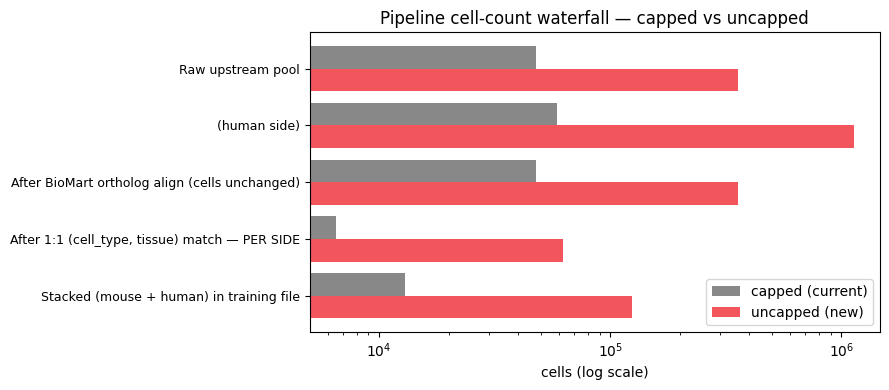

In [4]:
waterfall = pd.DataFrame(
    [
        ("Raw upstream pool",
         int(summary_raw["mouse_capped_cells"]),
         int(summary_raw["mouse_uncapped_cells"])),
        ("(human side)",
         int(summary_raw["human_capped_cells"]),
         int(summary_raw["human_uncapped_cells"])),
        ("After BioMart ortholog align (cells unchanged)",
         int(summary_raw["mouse_capped_cells"]),
         int(summary_raw["mouse_uncapped_cells"])),
        ("After 1:1 (cell_type, tissue) match — PER SIDE",
         6495,
         int(summary_raw["matched_pairs_uncapped"])),
        ("Stacked (mouse + human) in training file",
         12990,
         2 * int(summary_raw["matched_pairs_uncapped"])),
    ],
    columns=["stage", "capped", "uncapped"],
)
waterfall["ratio_uncapped_to_capped"] = (waterfall["uncapped"] / waterfall["capped"]).round(2)
display(waterfall)

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(waterfall))
ax.barh(y - 0.2, waterfall["capped"], height=0.4, label="capped (current)", color="#888")
ax.barh(y + 0.2, waterfall["uncapped"], height=0.4, label="uncapped (new)", color="#f2555b")
ax.set_yticks(y)
ax.set_yticklabels(waterfall["stage"], fontsize=9)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("cells (log scale)")
ax.set_title("Pipeline cell-count waterfall — capped vs uncapped")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Per-cell-type composition shift — what got added, what's new, what didn't move

Three groups of rows are interesting:

1. **Cell types that grew significantly.** These were capped before, and their counts now reflect the full atlas distribution. The B cell row is the most extreme single change (406 → 38,292).
2. **Cell types that are brand-new in the matched pool** (capped count = 0). These existed in the raw atlas on both sides but got squeezed below the matcher's per-identity floor by the 1000-cap. Removing the cap let them clear the matcher.
3. **Cell types that didn't move.** These were already below the 1000-cap on both sides — the cap wasn't binding for them. Notably: hematopoietic stem cell (1,584 in both), thymocyte (910), pulmonary alveolar type 2 cell (584). **For the BCG (LT-HSC) use case this is the honest framing: HSC count is unchanged.** The argument for this experiment is not "more HSC cells" but "a more diverse autoencoder latent space".


In [5]:
tbl = pd.read_csv(PERCELLTYPE_CSV).set_index("cell_type")
tbl["ratio_uncapped_to_capped"] = np.where(
    tbl["capped_n"] > 0,
    (tbl["uncapped_n"] / tbl["capped_n"]).round(1),
    np.inf,  # new cell types: capped was 0
)
tbl_sorted = tbl.sort_values("uncapped_n", ascending=False)
print(f"Total cell types in uncapped matched pool: {len(tbl_sorted)}")
print(f"  - already present in capped pool : {(tbl_sorted['capped_n'] > 0).sum()}")
print(f"  - new in uncapped pool           : {(tbl_sorted['capped_n'] == 0).sum()}")
print(f"  - unchanged (delta = 0)          : {(tbl_sorted['delta_uncapped_minus_capped'] == 0).sum()}")
print()
print("Full table sorted by uncapped count:")
display(tbl_sorted.head(40))


Total cell types in uncapped matched pool: 44
  - already present in capped pool : 30
  - new in uncapped pool           : 14
  - unchanged (delta = 0)          : 7

Full table sorted by uncapped count:


,capped_n,uncapped_n,delta_uncapped_minus_capped,ratio_uncapped_to_capped
cell_type,,,,
B cell,406,38292,37886,94.3
hepatocyte,0,8182,8182,inf
macrophage,204,7702,7498,37.8
endothelial cell,406,7300,6894,18.0
natural killer cell,912,6076,5164,6.7
luminal epithelial cell of mammary gland,0,5342,5342,inf
monocyte,166,4212,4046,25.4
fibroblast,76,3788,3712,49.8
basal cell,0,3638,3638,inf


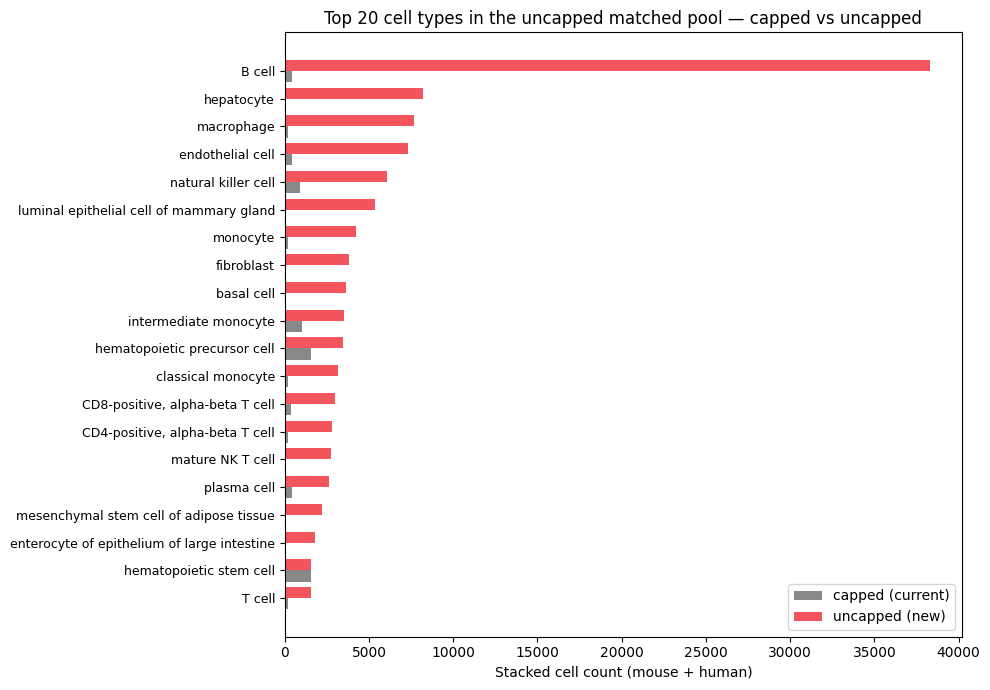

In [6]:
top20 = tbl_sorted.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(top20))
ax.barh(y - 0.2, top20["capped_n"], height=0.4, label="capped (current)", color="#888")
ax.barh(y + 0.2, top20["uncapped_n"], height=0.4, label="uncapped (new)", color="#f2555b")
ax.set_yticks(y)
ax.set_yticklabels(top20.index, fontsize=9)
ax.set_xlabel("Stacked cell count (mouse + human)")
ax.set_title("Top 20 cell types in the uncapped matched pool — capped vs uncapped")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


### 4a. Cell types newly added to the matched pool

These cell types existed in raw tabula on both sides but never made it into a matched pair under the cap. Removing the cap restores them.


14 cell types newly appearing in uncapped matched pool
They contribute 27026 stacked cells (13513 pairs).


,uncapped_n,share_of_added
cell_type,,
hepatocyte,8182,30.27
luminal epithelial cell of mammary gland,5342,19.77
basal cell,3638,13.46
mature NK T cell,2736,10.12
mesenchymal stem cell of adipose tissue,2204,8.16
enterocyte of epithelium of large intestine,1796,6.65
granulocyte,1348,4.99
adventitial cell,1162,4.30
endothelial cell of lymphatic vessel,280,1.04


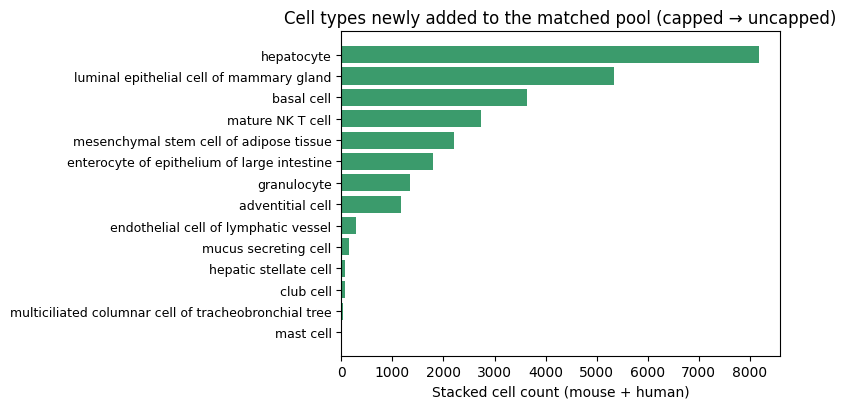

In [7]:
new_types = tbl_sorted[tbl_sorted["capped_n"] == 0].copy()
new_types["share_of_added"] = (
    new_types["uncapped_n"] / new_types["uncapped_n"].sum() * 100
).round(2)
print(f"{len(new_types)} cell types newly appearing in uncapped matched pool")
print(f"They contribute {int(new_types['uncapped_n'].sum())} stacked cells "
      f"({new_types['uncapped_n'].sum() / 2:.0f} pairs).")
display(new_types[["uncapped_n", "share_of_added"]])

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(new_types))))
y = np.arange(len(new_types))
ax.barh(y, new_types["uncapped_n"], color="#3b9b6c")
ax.set_yticks(y)
ax.set_yticklabels(new_types.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Stacked cell count (mouse + human)")
ax.set_title("Cell types newly added to the matched pool (capped → uncapped)")
fig.tight_layout()
plt.show()


### 4b. Cell types that didn't move (cap wasn't binding)

For these cell types the per-species count was already ≤ 1000 on at least one side. The matcher (which keeps `min(n_mouse, n_human)`) was already constrained by the smaller side, not by the cap, so removing the cap changes nothing. This includes a few that matter biologically — **HSC stays at 1,584 (relevant for the BCG line)**, thymocyte at 910, pulmonary alveolar type 2 at 584.


In [8]:
unchanged = tbl_sorted[
    (tbl_sorted["delta_uncapped_minus_capped"] == 0)
    & (tbl_sorted["capped_n"] > 0)
].copy()
print(f"{len(unchanged)} cell types unchanged between capped and uncapped pools.")
print("They account for {} stacked cells = {} matched pairs.".format(
    int(unchanged["uncapped_n"].sum()), int(unchanged["uncapped_n"].sum() / 2)))
display(unchanged[["capped_n", "uncapped_n"]])


7 cell types unchanged between capped and uncapped pools.
They account for 3646 stacked cells = 1823 matched pairs.


,capped_n,uncapped_n
cell_type,,
hematopoietic stem cell,1584,1584
thymocyte,910,910
pulmonary alveolar type 2 cell,584,584
bronchial smooth muscle cell,440,440
myeloid dendritic cell,66,66
plasmacytoid dendritic cell,54,54
pulmonary alveolar type 1 cell,8,8


## 5. CD8 holdout — the cells the experiment is evaluated on

CD8 is held out at training time via `toggle_ood` (`holdout='CL:0000625'`, `mode=ood`, `random_state=0`). Half of the CD8 cells go into the "ignore" bucket (excluded entirely), and half into the "ood" bucket (the evaluation set). The R² we report at the end is computed on the OOD half.

The capped baseline had ~195 mouse + ~195 human CD8 cells matched → ~98 of each per species in the OOD eval set. That is barely enough cells to estimate a stable mean expression vector, which is why the eval pipeline subsamples three times (`n_cells=30,50,80`) and reports the spread.

In the uncapped variant we have 7.7× more CD8 to work with.


In [9]:
cd8_stacked_capped = int(tbl.loc["CD8-positive, alpha-beta T cell", "capped_n"])
cd8_stacked_uncapped = int(tbl.loc["CD8-positive, alpha-beta T cell", "uncapped_n"])

cd8_per_species_capped = cd8_stacked_capped // 2
cd8_per_species_uncapped = cd8_stacked_uncapped // 2

# toggle_ood mode=ood with test_size=0.2 puts half of holdout cells into "ood" (the eval set).
cd8_eval_per_species_capped = cd8_per_species_capped // 2
cd8_eval_per_species_uncapped = cd8_per_species_uncapped // 2

cd8_tbl = pd.DataFrame(
    {
        "capped": [cd8_stacked_capped, cd8_per_species_capped, cd8_eval_per_species_capped],
        "uncapped": [cd8_stacked_uncapped, cd8_per_species_uncapped, cd8_eval_per_species_uncapped],
    },
    index=[
        "CD8 stacked (mouse + human, matched)",
        "CD8 per species",
        "CD8 per species in OOD eval slice (toggle_ood half)",
    ],
)
cd8_tbl["ratio"] = (cd8_tbl["uncapped"] / cd8_tbl["capped"]).round(2)
cd8_tbl


,capped,uncapped,ratio
"CD8 stacked (mouse + human, matched)",390,2996,7.68
CD8 per species,195,1498,7.68
CD8 per species in OOD eval slice (toggle_ood half),97,749,7.72


## 6. Distribution balance — is "more" also "more balanced"?

A purely quantitative answer: no. Removing the cap restores the **natural** distribution of cell-type abundances in the raw atlas, which is itself heavily skewed (B cells, hepatocytes, macrophages dominate; rare populations stay rare). The cap was an implicit (and bad) form of class-balancing — it flattened the most populous types down to 1000. Without it, the imbalance ratio between most-populous and least-populous goes up.

If we **also** want balance (which is the **Proposal C** in the meeting briefing — per-`(cell_type, tissue)` quota at match time), that's a separate change to `match_cells_by_celltype_tissue`. For this experiment we keep the matcher as-is to isolate the cap-removal effect.


In [10]:
def gini(counts):
    """Standard Gini coefficient — 0 = perfectly uniform, 1 = single class dominates."""
    a = np.sort(np.asarray(counts, dtype=float))
    a = a[a > 0]
    n = a.size
    if n == 0:
        return 0.0
    cum = np.cumsum(a)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n


cap_counts = tbl["capped_n"][tbl["capped_n"] > 0]
unc_counts = tbl["uncapped_n"][tbl["uncapped_n"] > 0]

balance = pd.DataFrame(
    {
        "capped": [
            int(cap_counts.sum()),
            int(cap_counts.size),
            int(cap_counts.max()),
            int(cap_counts.min()),
            f"{cap_counts.max() / cap_counts.min():.0f}×",
            f"{gini(cap_counts):.3f}",
        ],
        "uncapped": [
            int(unc_counts.sum()),
            int(unc_counts.size),
            int(unc_counts.max()),
            int(unc_counts.min()),
            f"{unc_counts.max() / unc_counts.min():.0f}×",
            f"{gini(unc_counts):.3f}",
        ],
    },
    index=[
        "total stacked cells",
        "non-empty cell types",
        "largest cell-type bucket",
        "smallest cell-type bucket",
        "max / min ratio",
        "Gini coefficient (lower = more balanced)",
    ],
)
balance


,capped,uncapped
total stacked cells,12990,124886
non-empty cell types,30,44
largest cell-type bucket,1584,38292
smallest cell-type bucket,2,4
max / min ratio,792×,9573×
Gini coefficient (lower = more balanced),0.515,0.666


## 7. Sanity check — read the actual training file back

The h5ad file the trainer reads has shape `(124,886, 1000)` with the right `.obs` columns. Confirm by reading just the obs.


In [11]:
unc = ad.read_h5ad(UNCAPPED_H5)
print("file              :", UNCAPPED_H5)
print("shape             :", unc.shape)
print("obs columns       :", list(unc.obs.columns))
print("species counts    :", unc.obs["species"].value_counts().to_dict())
print("CD8 cells in file :", int((unc.obs["cell_type_ontology_term_id"].astype(str) == "CL:0000625").sum()))
print()
print("Per-species counts for CD8 (these are what toggle_ood will split):")
display(
    unc.obs[unc.obs["cell_type_ontology_term_id"].astype(str) == "CL:0000625"]
    ["species"].value_counts()
)


file              : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_a_uncapped_v07.h5ad
shape             : (124886, 1000)
obs columns       : ['cell_type', 'cell_type_ontology_term_id', 'condition', 'donor_id', 'species', 'tissue', 'tissue_ontology_term_id']
species counts    : {'human': 62443, 'mouse': 62443}
CD8 cells in file : 2996

Per-species counts for CD8 (these are what toggle_ood will split):


species
human    1498
mouse    1498
Name: count, dtype: int64

## 8. Trained-model comparison — submitted jobs and expected outputs

Same architectures, same hyperparameters, same `toggle_ood` (`holdout='CL:0000625'`, mode=ood, random_state=0). Only the training data file differs.

| | Capped baseline (already trained) | Uncapped variant (submitted today) |
|---|---|---|
| Results dir | `cellot/cellot_gpu/results/hvg_pearson_residuals_a_ood/` | `cellot/cellot_gpu/results/hvg_pearson_residuals_a_ood_uncapped/` |
| Training data | `hvg_pearson_residuals_a_v07.h5ad` (12,990 × 1000) | `hvg_pearson_residuals_a_uncapped_v07.h5ad` (124,886 × 1000) |
| scGen train JID | (historical) | `15997359` |
| IMPACT_CellOT train JID | (historical) | `15997360` (depends on scGen) |
| scGen eval JID | (historical) | `15997361` (depends on scGen train) |
| IMPACT_CellOT eval JID | (historical) | `15997362` (depends on IMPACT train) |

The eval scripts at `sbatch/eval_dataspace/eval_hvg_pearson_residuals_a_ood_uncapped_*_dataspace.sbatch` will write `evals.csv` to `results/hvg_pearson_residuals_a_ood_uncapped/{scgen,impact_cellot}/evals_ood_data_space/`. The comparable baseline numbers (Pearson r squared, `n_cells=30`, data space) are:

| Model | Baseline (capped) |
|---|---|
| scGen | 0.869 |
| IMPACT_CellOT | 0.862 |

The next cell pulls live status from `sacct`, plus the baseline-vs-uncapped eval numbers when they exist.


In [3]:
import subprocess

CHAIN_CSV = BASE / "scripts/.submitted_uncapped_a_ood_chain.csv"
RESULTS_NEW = BASE / "cellot/cellot_gpu/results/hvg_pearson_residuals_a_ood_uncapped"
RESULTS_BASELINE = BASE / "cellot/cellot_gpu/results/hvg_pearson_residuals_a_ood"

jids = CHAIN_CSV.read_text().strip()
print(f"Submitted chain JIDs: {jids}")
print()
print("--- sacct status ---")
out = subprocess.run(
    ["sacct", "-j", jids,
     "--format=JobID%10,JobName%24,State,Elapsed,ExitCode"],
    capture_output=True, text=True,
)
print(out.stdout)

print("--- baseline (capped) vs uncapped eval comparison ---")
for sub in ("scgen", "impact_cellot"):
    base_csv = RESULTS_BASELINE / sub / "evals_ood_data_space" / "evals.csv"
    new_csv = RESULTS_NEW / sub / "evals_ood_data_space" / "evals.csv"
    if not base_csv.exists():
        print(f"[{sub}] baseline evals.csv missing"); continue
    base = pd.read_csv(base_csv)
    base_r2 = base[(base["metric"] == "r2-means") & (base["nfeatures"] == "all")].copy()
    base_r2["R2"] = base_r2["value"].astype(float) ** 2
    print(f"\n[{sub}] baseline (capped) R² of means by n_cells (Pearson r squared):")
    print(base_r2[["ncells", "value", "R2"]].rename(columns={"value": "pearson_r"}).to_string(index=False))
    if new_csv.exists():
        new = pd.read_csv(new_csv)
        new_r2 = new[(new["metric"] == "r2-means") & (new["nfeatures"] == "all")].copy()
        new_r2["R2"] = new_r2["value"].astype(float) ** 2
        print(f"[{sub}] UNCAPPED R² of means by n_cells:")
        print(new_r2[["ncells", "value", "R2"]].rename(columns={"value": "pearson_r"}).to_string(index=False))
    else:
        print(f"[{sub}] uncapped evals not yet written (jobs still running)")


Submitted chain JIDs: 15997359,16001391,15997361,16001393

--- sacct status ---
     JobID                  JobName      State    Elapsed ExitCode 
---------- ------------------------ ---------- ---------- -------- 
  15997359          pe_a_ood_unc_sg  COMPLETED   00:22:33      0:0 
15997359.+                    batch  COMPLETED   00:22:33      0:0 
15997359.+                   extern  COMPLETED   00:22:33      0:0 
  15997361        pe_a_ood_unc_sgds  COMPLETED   00:02:31      0:0 
15997361.+                    batch  COMPLETED   00:02:31      0:0 
15997361.+                   extern  COMPLETED   00:02:31      0:0 
  16001391         pe_a_ood_unc_imp  COMPLETED   00:56:09      0:0 
16001391.+                    batch  COMPLETED   00:56:09      0:0 
16001391.+                   extern  COMPLETED   00:56:09      0:0 
  16001393        pe_a_ood_unc_imds  COMPLETED   00:01:23      0:0 
16001393.+                    batch  COMPLETED   00:01:23      0:0 
16001393.+                   extern 

## 9. Headline results — capped vs uncapped, side-by-side

Reads `evals.csv` from both result directories and prints the comparison. Works progressively: as long as the baseline (capped) `evals.csv` exists, the table is populated; rows for models whose uncapped eval hasn't finished yet are shown as `(eval pending)`.

**Re-run this cell anytime** to refresh after a job finishes. The full chain is:

```
scgen train (15997359, ~22m) → COMPLETED 12:42
  ├── scgen eval (15997361, ~3m)            → COMPLETED 12:46
  └── impact_cellot train (15997360, ~12h)  → RUNNING since 12:42
        └── impact_cellot eval (15997362, ~3m)  → pending impact train
```

**What "better" means here**:
- `r2-means` is **Pearson r** between predicted-human-mean and actual-human-mean gene-expression vectors on the held-out CD8 cells. Higher is better. We square it to get `R²`.
- `mmd` is maximum mean discrepancy between predicted-human and actual-human cell distributions. Lower is better.
- All numbers are in **data space** (decoded back to 1000-d gene expression), `--setting ood` (eval slice = the held-out CD8 cells), at three subsample sizes (30, 50, 80 cells).


In [4]:
def load_eval_pivot(csv_path: Path) -> pd.DataFrame | None:
    """Load evals.csv, average across any duplicated (ncells, metric) rows, pivot to
    (ncells × metric) shape, add a squared-R² column."""
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    sub = df[df["nfeatures"] == "all"].copy()
    if sub.empty:
        return None
    piv = sub.pivot_table(index="ncells", columns="metric", values="value", aggfunc="mean")
    if "r2-means" in piv.columns:
        piv["R²"] = piv["r2-means"] ** 2
    return piv


def comparison_table(model_subdir: str) -> pd.DataFrame:
    """Return a side-by-side capped vs uncapped pivot for one model."""
    base = load_eval_pivot(RESULTS_BASELINE / model_subdir / "evals_ood_data_space" / "evals.csv")
    new = load_eval_pivot(RESULTS_NEW / model_subdir / "evals_ood_data_space" / "evals.csv")
    if base is None and new is None:
        return pd.DataFrame()
    cols_keep = ["r2-means", "R²", "mmd"]
    if base is not None:
        base = base[[c for c in cols_keep if c in base.columns]]
        base.columns = pd.MultiIndex.from_product([["capped"], base.columns])
    if new is not None:
        new = new[[c for c in cols_keep if c in new.columns]]
        new.columns = pd.MultiIndex.from_product([["uncapped"], new.columns])
    if base is None:
        return new
    if new is None:
        return base
    both = base.join(new, how="outer")
    both[("Δ", "ΔR² (uncapped − capped)")] = both[("uncapped", "R²")] - both[("capped", "R²")]
    both[("Δ", "ΔMMD (uncapped − capped)")] = both[("uncapped", "mmd")] - both[("capped", "mmd")]
    return both


from IPython.display import display, Markdown

display(Markdown("### scGen baseline (one-shot mean-shift in latent space)"))
sg_table = comparison_table("scgen")
if sg_table.empty:
    print("(no scGen eval files found at all)")
elif ("uncapped", "R²") not in sg_table.columns:
    display(sg_table.round(4))
    print("\n(scGen uncapped eval still pending — re-run this cell after it finishes)")
else:
    display(sg_table.round(4))

display(Markdown("### IMPACT_CellOT (ICNN-parameterized neural OT in latent space)"))
imp_table = comparison_table("impact_cellot")
if imp_table.empty:
    print("(no IMPACT_CellOT eval files found at all)")
elif ("uncapped", "R²") not in imp_table.columns:
    display(imp_table.round(4))
    print("\n(IMPACT_CellOT uncapped eval still pending — re-run this cell after it finishes)")
else:
    display(imp_table.round(4))


### scGen baseline (one-shot mean-shift in latent space)

capped                 uncapped                  \
metric r2-means      R²     mmd r2-means      R²     mmd   
ncells                                                     
30       0.9196  0.8456  0.1622   0.9542  0.9105  0.1425   
50       0.9218  0.8496  0.1363   0.9623  0.9260  0.1289   
80       0.9260  0.8575  0.1250   0.9654  0.9321  0.1163   

                             Δ                           
metric ΔR² (uncapped − capped) ΔMMD (uncapped − capped)  
ncells                                                   
30                      0.0649                  -0.0197  
50                      0.0764                  -0.0074  
80                      0.0745                  -0.0087

### IMPACT_CellOT (ICNN-parameterized neural OT in latent space)

capped                 uncapped                  \
metric r2-means      R²     mmd r2-means      R²     mmd   
ncells                                                     
30       0.9367  0.8774  0.1393   0.9111  0.8301  0.0875   
50       0.9443  0.8916  0.1176   0.9178  0.8424  0.0644   
80       0.9469  0.8966  0.1046   0.9208  0.8478  0.0513   

                             Δ                           
metric ΔR² (uncapped − capped) ΔMMD (uncapped − capped)  
ncells                                                   
30                     -0.0474                  -0.0519  
50                     -0.0492                  -0.0532  
80                     -0.0488                  -0.0533